# Support Vector Machine (SVM)

This notebook is a complete and beginner-friendly guide to **Support Vector Machines (SVM)**.

What you will learn:
1. What SVM is and why it works
2. Geometric intuition: hyperplane, margin, support vectors
3. Hard margin vs soft margin
4. Kernels (linear, polynomial, RBF)
5. Role of `C`, `gamma`, and `kernel`
6. End-to-end SVM classification workflow
7. Hyperparameter tuning with `GridSearchCV`
8. Handling imbalanced data with SVM
9. SVM for regression (`SVR`)
10. Practical tips and common mistakes

Goal: By the end, you should be able to **understand SVM theory** and **code SVM models confidently**.

## 1) Core Intuition of SVM

SVM tries to find a decision boundary (hyperplane) that separates classes with the **maximum possible margin**.

- A **hyperplane** is a line in 2D, a plane in 3D, and a higher-dimensional separator in general.
- **Margin** = distance from hyperplane to the nearest points from each class.
- The points that touch the margin are called **support vectors**.

Why maximize margin?
- Larger margin usually means better generalization on unseen data.

In simple words:
- Many lines can separate classes, but SVM chooses the one with the **safest gap** between classes.

## 2) Math Idea (Without Overcomplication)

For binary classification, SVM learns:

$$f(x) = w^T x + b$$

Prediction rule:
- Class 1 if $f(x) > 0$
- Class 0 (or -1) if $f(x) < 0$

### Hard Margin SVM (perfectly separable data)
It tries to maximize margin, equivalent to minimizing:

$$\frac{1}{2} \|w\|^2$$

subject to correct separation constraints.

### Soft Margin SVM (real-world data)
Real data has noise and overlap, so SVM allows some violations using slack variables and penalty `C`.

Interpretation of `C`:
- Large `C`: tries hard to classify all training points correctly (may overfit).
- Small `C`: allows more violations for a wider margin (may generalize better).

### Kernel Trick
If data is not linearly separable in original space, kernel maps it implicitly to a higher-dimensional space where separation is easier.

Common kernels:
- `linear`
- `poly`
- `rbf` (most commonly useful default)
- `sigmoid` (less common in practice)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.svm import SVC, SVR
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    mean_squared_error,
    r2_score,
)
from sklearn.datasets import make_blobs, make_moons, load_breast_cancer, make_classification

sns.set_theme(style="whitegrid")
np.random.seed(42)


def plot_decision_boundary(model, X, y, title="Decision Boundary", ax=None):
    """Plot classification boundary for 2D features."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 5))

    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )
    grid = np.c_[xx.ravel(), yy.ravel()]

    Z = model.predict(grid)
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.25, cmap="coolwarm")
    scatter = ax.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolor="k")
    ax.set_title(title)
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")
    return ax, scatter

## 3) Linear SVM on a Simple Dataset

We start with linearly separable synthetic data so the behavior is easy to see.

Important: SVM is sensitive to feature scale, so we use `StandardScaler` inside a pipeline.

In [2]:
# Create simple linearly separable data
X, y = make_blobs(
    n_samples=300,
    centers=2,
    n_features=2,
    cluster_std=1.3,
    random_state=42,
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

linear_svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="linear", C=1.0)),
])

linear_svm_pipeline.fit(X_train, y_train)
y_pred = linear_svm_pipeline.predict(X_test)

print("Linear SVM Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Linear SVM Accuracy: 1.0

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        38
           1       1.00      1.00      1.00        37

    accuracy                           1.00        75
   macro avg       1.00      1.00      1.00        75
weighted avg       1.00      1.00      1.00        75



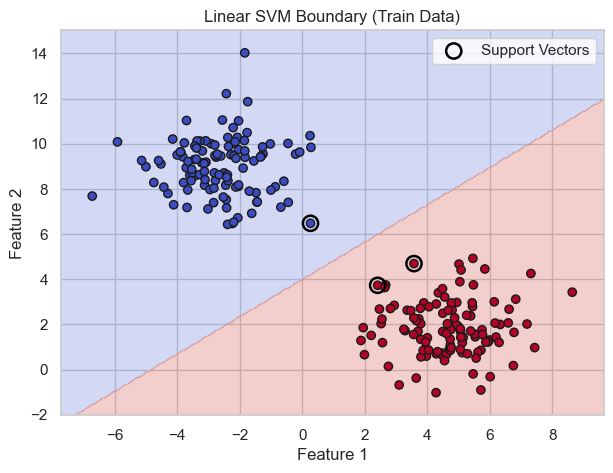

Number of support vectors for each class: [1 2]
Total support vectors: 3


In [3]:
# Visualize decision boundary for linear SVM
# (Train another linear SVC directly on raw X only for 2D plotting convenience.)
plot_model = SVC(kernel="linear", C=1.0)
plot_model.fit(X_train, y_train)

fig, ax = plt.subplots(figsize=(7, 5))
plot_decision_boundary(plot_model, X_train, y_train, title="Linear SVM Boundary (Train Data)", ax=ax)

# Highlight support vectors
sv = plot_model.support_vectors_
ax.scatter(sv[:, 0], sv[:, 1], s=120, facecolors="none", edgecolors="black", linewidths=1.8, label="Support Vectors")
ax.legend()
plt.show()

print("Number of support vectors for each class:", plot_model.n_support_)
print("Total support vectors:", plot_model.support_.shape[0])

## 4) Why Kernels Are Needed

Some datasets are not separable by a straight line.

Example intuition:
- If class A is inside a circle and class B is outside, no straight line can separate them.
- Kernel SVM (especially `rbf`) can create nonlinear boundaries.

### `gamma` in RBF kernel
- High `gamma`: very flexible boundary (can overfit).
- Low `gamma`: smoother boundary (can underfit).

Together, `C` and `gamma` control model complexity.

In [4]:
# Create nonlinear data
X_moon, y_moon = make_moons(n_samples=350, noise=0.22, random_state=42)

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_moon, y_moon, test_size=0.25, random_state=42, stratify=y_moon
)

# Model 1: Linear SVM
linear_model = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="linear", C=1.0)),
])
linear_model.fit(X_train_m, y_train_m)

# Model 2: RBF SVM
rbf_model = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", C=1.0, gamma="scale")),
])
rbf_model.fit(X_train_m, y_train_m)

pred_linear = linear_model.predict(X_test_m)
pred_rbf = rbf_model.predict(X_test_m)

print("Linear kernel accuracy:", round(accuracy_score(y_test_m, pred_linear), 4))
print("RBF kernel accuracy   :", round(accuracy_score(y_test_m, pred_rbf), 4))

Linear kernel accuracy: 0.875
RBF kernel accuracy   : 0.9545


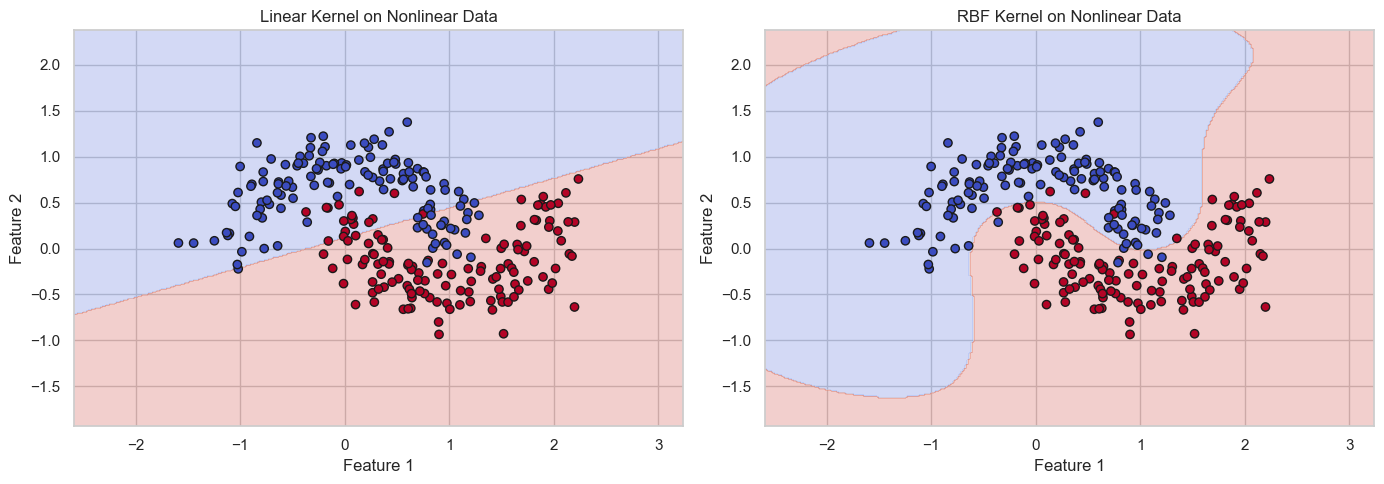

In [5]:
# Visual comparison: Linear vs RBF boundary
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_decision_boundary(
    linear_model,
    X_train_m,
    y_train_m,
    title="Linear Kernel on Nonlinear Data",
    ax=axes[0],
)

plot_decision_boundary(
    rbf_model,
    X_train_m,
    y_train_m,
    title="RBF Kernel on Nonlinear Data",
    ax=axes[1],
)

plt.tight_layout()
plt.show()

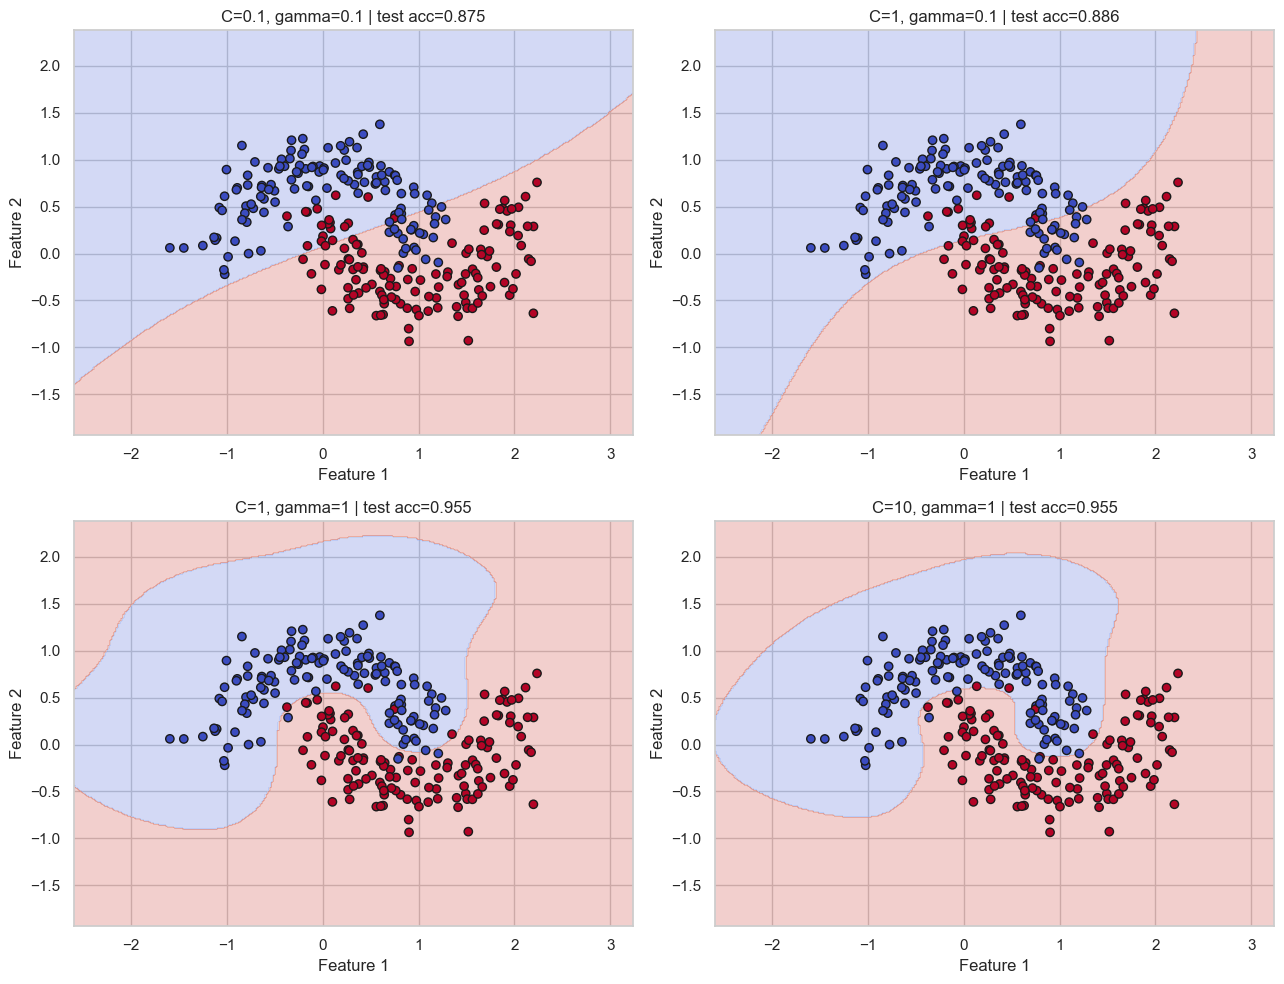

In [6]:
# Effect of C and gamma on decision boundary
param_settings = [
    {"C": 0.1, "gamma": 0.1},
    {"C": 1, "gamma": 0.1},
    {"C": 1, "gamma": 1},
    {"C": 10, "gamma": 1},
]

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.ravel()

for ax, params in zip(axes, param_settings):
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(kernel="rbf", C=params["C"], gamma=params["gamma"])),
    ])
    model.fit(X_train_m, y_train_m)
    acc = accuracy_score(y_test_m, model.predict(X_test_m))
    title = f"C={params['C']}, gamma={params['gamma']} | test acc={acc:.3f}"
    plot_decision_boundary(model, X_train_m, y_train_m, title=title, ax=ax)

plt.tight_layout()
plt.show()

## 5) Real Dataset Workflow with Hyperparameter Tuning

Now we use a real dataset and proper model selection.

Workflow:
1. Split data
2. Build pipeline (`StandardScaler` + `SVC`)
3. Tune hyperparameters with cross-validation
4. Evaluate on test set

This is the recommended production-style approach.

In [7]:
# Load real-world dataset
cancer = load_breast_cancer()
X_real = cancer.data
y_real = cancer.target

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_real, y_real, test_size=0.2, random_state=42, stratify=y_real
)

svc_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC()),
])

param_grid = {
    "svc__kernel": ["linear", "rbf"],
    "svc__C": [0.1, 1, 10, 100],
    "svc__gamma": ["scale", 0.01, 0.1, 1],
}

grid = GridSearchCV(
    estimator=svc_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
)

grid.fit(X_train_r, y_train_r)

print("Best Parameters:", grid.best_params_)
print("Best CV Accuracy:", round(grid.best_score_, 4))

best_model = grid.best_estimator_
y_pred_r = best_model.predict(X_test_r)

print("\nTest Accuracy:", round(accuracy_score(y_test_r, y_pred_r), 4))
print("\nClassification Report:\n")
print(classification_report(y_test_r, y_pred_r, target_names=cancer.target_names))

Best Parameters: {'svc__C': 10, 'svc__gamma': 0.01, 'svc__kernel': 'rbf'}
Best CV Accuracy: 0.9802

Test Accuracy: 0.9825

Classification Report:

              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



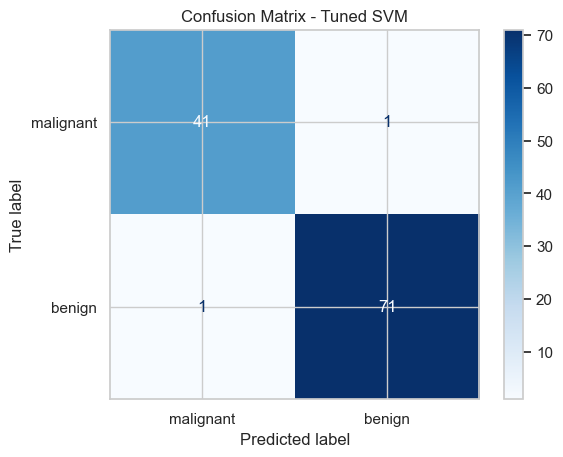

In [8]:
# Confusion matrix for best model
cm = confusion_matrix(y_test_r, y_pred_r)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=cancer.target_names).plot(cmap="Blues")
plt.title("Confusion Matrix - Tuned SVM")
plt.show()

## 6) SVM with Imbalanced Data

When one class has far fewer samples, accuracy can be misleading.

Useful strategy:
- Set `class_weight='balanced'` in `SVC`.

This increases penalty for mistakes on minority class and usually improves minority recall.

In [9]:
# Build imbalanced binary dataset
X_imb, y_imb = make_classification(
    n_samples=1200,
    n_features=10,
    n_informative=6,
    n_redundant=2,
    weights=[0.92, 0.08],
    flip_y=0.01,
    random_state=42,
)

X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(
    X_imb, y_imb, test_size=0.25, random_state=42, stratify=y_imb
)

model_plain = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(kernel="rbf", C=1.0, gamma="scale")),
])

model_balanced = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(kernel="rbf", C=1.0, gamma="scale", class_weight="balanced")),
])

model_plain.fit(X_train_i, y_train_i)
model_balanced.fit(X_train_i, y_train_i)

pred_plain = model_plain.predict(X_test_i)
pred_bal = model_balanced.predict(X_test_i)

print("Without class_weight='balanced'\n")
print(classification_report(y_test_i, pred_plain))

print("With class_weight='balanced'\n")
print(classification_report(y_test_i, pred_bal))

Without class_weight='balanced'

              precision    recall  f1-score   support

           0       0.94      1.00      0.97       274
           1       1.00      0.38      0.56        26

    accuracy                           0.95       300
   macro avg       0.97      0.69      0.76       300
weighted avg       0.95      0.95      0.94       300

With class_weight='balanced'

              precision    recall  f1-score   support

           0       0.97      0.95      0.96       274
           1       0.58      0.69      0.63        26

    accuracy                           0.93       300
   macro avg       0.78      0.82      0.80       300
weighted avg       0.94      0.93      0.93       300



## 7) SVM for Regression (SVR)

SVM is not only for classification.

For regression, SVR tries to fit a function while keeping prediction errors inside an epsilon tube.

Key SVR parameters:
- `kernel`
- `C`
- `gamma` (for RBF)
- `epsilon` (tube width)

A larger `epsilon` ignores small errors, often producing smoother predictions.

In [10]:
# Synthetic regression data
rng = np.random.RandomState(42)
X_reg = np.sort(5 * rng.rand(180, 1), axis=0)
y_reg = np.sin(X_reg).ravel() + 0.15 * rng.randn(180)

X_train_g, X_test_g, y_train_g, y_test_g = train_test_split(
    X_reg, y_reg, test_size=0.25, random_state=42
)

svr_rbf = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", SVR(kernel="rbf", C=30, gamma=1.0, epsilon=0.1)),
])

svr_linear = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", SVR(kernel="linear", C=10, epsilon=0.1)),
])

svr_rbf.fit(X_train_g, y_train_g)
svr_linear.fit(X_train_g, y_train_g)

pred_rbf = svr_rbf.predict(X_test_g)
pred_lin = svr_linear.predict(X_test_g)

print("SVR (RBF)  RMSE:", round(np.sqrt(mean_squared_error(y_test_g, pred_rbf)), 4))
print("SVR (RBF)  R2  :", round(r2_score(y_test_g, pred_rbf), 4))
print("SVR (Linear) RMSE:", round(np.sqrt(mean_squared_error(y_test_g, pred_lin)), 4))
print("SVR (Linear) R2  :", round(r2_score(y_test_g, pred_lin), 4))

SVR (RBF)  RMSE: 0.1544
SVR (RBF)  R2  : 0.9502
SVR (Linear) RMSE: 0.414
SVR (Linear) R2  : 0.6419


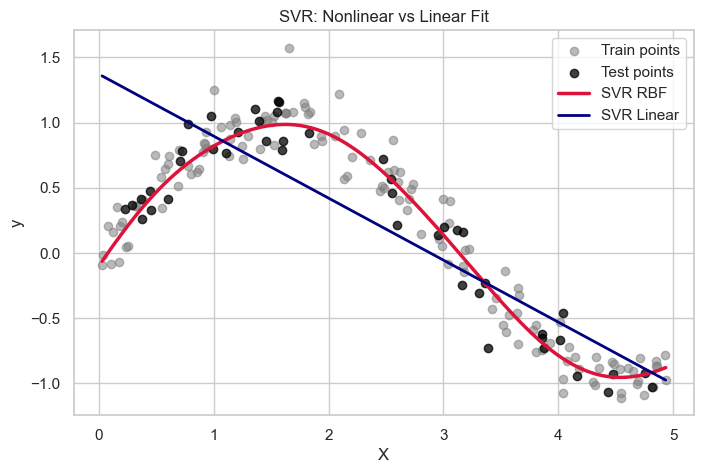

In [11]:
# Visualize SVR predictions
x_line = np.linspace(X_reg.min(), X_reg.max(), 300).reshape(-1, 1)

y_line_rbf = svr_rbf.predict(x_line)
y_line_lin = svr_linear.predict(x_line)

plt.figure(figsize=(8, 5))
plt.scatter(X_train_g, y_train_g, color="gray", alpha=0.55, label="Train points")
plt.scatter(X_test_g, y_test_g, color="black", alpha=0.75, label="Test points")
plt.plot(x_line, y_line_rbf, color="crimson", linewidth=2.5, label="SVR RBF")
plt.plot(x_line, y_line_lin, color="navy", linewidth=2.0, label="SVR Linear")
plt.title("SVR: Nonlinear vs Linear Fit")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

## 8) Practical Cheat Sheet

### When to use SVM
- Medium-sized datasets
- Clear class separation after transformation
- Need strong margins and robust generalization

### Must-do checklist
1. Always scale features (`StandardScaler`).
2. Start with `kernel='rbf'`, `C=1`, `gamma='scale'`.
3. Tune `C` and `gamma` using cross-validation.
4. For imbalanced data, try `class_weight='balanced'`.
5. Evaluate with precision/recall/F1, not only accuracy.

### Common mistakes
- Not scaling features
- Using only accuracy on imbalanced datasets
- Using very large `C` and `gamma` without validation
- Not using a pipeline (can cause data leakage)

### Multi-class note
`SVC` supports multi-class classification internally using one-vs-one strategy.

In [12]:
# Optional: save and load tuned SVM model
# Uncomment to use if joblib is installed.

# import joblib
# joblib.dump(best_model, "svm_best_model.pkl")
# loaded_model = joblib.load("svm_best_model.pkl")
# print("Loaded model test accuracy:", accuracy_score(y_test_r, loaded_model.predict(X_test_r)))

## 9) Practice Tasks

Try these to strengthen your understanding:
1. In the moons example, test kernels: `linear`, `poly`, `rbf` and compare metrics.
2. In the real dataset section, extend `param_grid` with `class_weight=[None, 'balanced']`.
3. In SVR, vary `epsilon` as `[0.01, 0.1, 0.5]` and compare RMSE.
4. Plot support vectors for one RBF classification model.

If you complete these tasks, you will be ready to apply SVM on your own datasets.